In [20]:
import pandas as pd

df = pd.read_csv("cleaned_financial_dataset.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (3440, 6)


,text,sentiment,text_length,cleaned_text,sentiment_encoded,cleaned_length
0,"According to Gran , the company has no plans t...",neutral,127,according gran company no plan move production...,1,78
1,With the new production plant the company woul...,positive,206,new production plant company would increase ca...,2,157
2,"For the last quarter of 2010 , Componenta 's n...",positive,193,last quarter 2010 componenta net sale doubled ...,2,123
3,"In the third quarter of 2010 , net sales incre...",positive,125,third quarter 2010 net sale increased 52 % eur...,2,88
4,Operating profit rose to EUR 13.1 mn from EUR ...,positive,122,operating profit rose eur 131 mn eur 87 mn cor...,2,95


In [21]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
label_encoder.fit(df["sentiment"])

print("Classes:", label_encoder.classes_)

Classes: ['negative' 'neutral' 'positive']


In [22]:
from sklearn.model_selection import train_test_split

X = df["cleaned_text"]
y = df["sentiment_encoded"]

# First split: Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split: Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Testing size:", X_test.shape)

Training size: (2408,)
Validation size: (516,)
Testing size: (516,)


In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

In [24]:
print("TF-IDF Shape (Training Set):", X_train_tfidf.shape)
print("TF-IDF Shape (Validation Set):", X_val_tfidf.shape)
print("TF-IDF Shape (Test Set):", X_test_tfidf.shape)

TF-IDF Shape (Training Set): (2408, 10000)
TF-IDF Shape (Validation Set): (516, 10000)
TF-IDF Shape (Test Set): (516, 10000)


In [25]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(X_train_tfidf, y_train)

log_pred = log_model.predict(X_test_tfidf)

In [26]:
def predict_sentiment_with_probability(text_input):
    # Preprocess same way as training (basic cleaning if needed)
    processed = tfidf.transform([text_input])
    
    # Get probability scores
    probabilities = log_model.predict_proba(processed)[0]
    
    # Get predicted class
    predicted_class = log_model.predict(processed)[0]
    
    # Map labels
    class_labels = label_encoder.classes_
    
    print("Input Text:", text_input)
    print("\nPredicted Sentiment:", class_labels[predicted_class])
    print("\nProbability Distribution:")
    
    for label, prob in zip(class_labels, probabilities):
        print(f"{label}: {prob*100:.2f}%")

In [27]:
sample_text = "The company reported record profit growth this quarter"

predict_sentiment_with_probability(sample_text)

Input Text: The company reported record profit growth this quarter

Predicted Sentiment: positive

Probability Distribution:
negative: 21.20%
neutral: 25.23%
positive: 53.58%


In [28]:
from sklearn.model_selection import cross_val_score
import numpy as np

print("🔹 Cross-Validation (5-Fold) Results")

# Logistic Regression CV
log_cv_scores = cross_val_score(
    LogisticRegression(max_iter=1000, class_weight="balanced"),
    X_train_tfidf,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Logistic Regression CV Accuracy:", log_cv_scores)
print("Logistic Regression CV Mean:", np.mean(log_cv_scores))



🔹 Cross-Validation (5-Fold) Results
Logistic Regression CV Accuracy: [0.78215768 0.79253112 0.81742739 0.78586279 0.7962578 ]
Logistic Regression CV Mean: 0.7948473529386393


In [29]:
# Validation Evaluation

from sklearn.metrics import accuracy_score

val_pred_log = log_model.predict(X_val_tfidf)

print("Validation Accuracy (Logistic):", accuracy_score(y_val, val_pred_log))


Validation Accuracy (Logistic): 0.8062015503875969


In [30]:
from sklearn.metrics import classification_report, accuracy_score

print("🔹 Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, log_pred))
print(classification_report(y_test, log_pred))



🔹 Logistic Regression Results
Accuracy: 0.7868217054263565
              precision    recall  f1-score   support

           0       0.74      0.59      0.65        63
           1       0.85      0.89      0.87       320
           2       0.65      0.64      0.64       133

    accuracy                           0.79       516
   macro avg       0.75      0.70      0.72       516
weighted avg       0.78      0.79      0.78       516



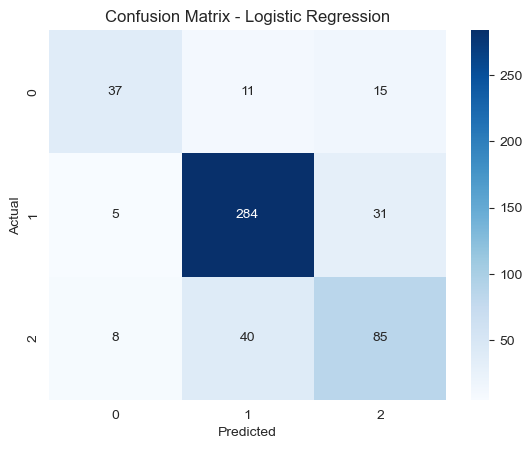

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

sns.set_style("whitegrid")

# Logistic Regression
cm_log = confusion_matrix(y_test, log_pred)

plt.figure()
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



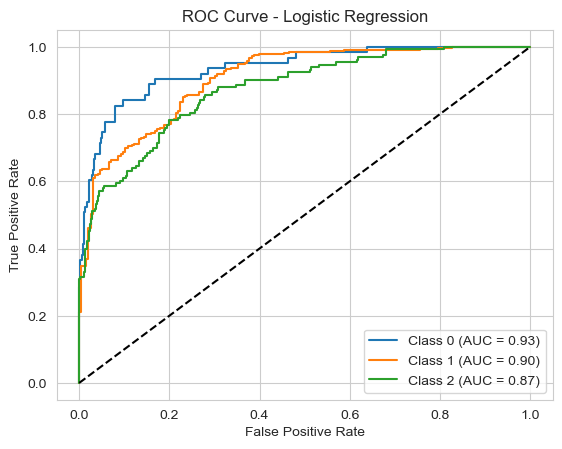

In [32]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

# Binarize labels
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

# Logistic Regression probabilities
log_probs = log_model.predict_proba(X_test_tfidf)

plt.figure()

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], log_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [33]:
import pickle

with open("financial_model.pkl", "wb") as f:
    pickle.dump(log_model, f)

with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

print("All files saved successfully.")

All files saved successfully.
